In [1]:
import json 
import numpy 
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
df = pd.read_json("5/metrics/metrics.jsonl", lines=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reward            200 non-null    float64
 1   human_reward      200 non-null    int64  
 2   bot_reward        200 non-null    float64
 3   human_steps       200 non-null    int64  
 4   bot_steps         200 non-null    int64  
 5   epsilon           200 non-null    float64
 6   human_population  200 non-null    int64  
 7   bot_population    200 non-null    int64  
 8   population        200 non-null    int64  
 9   conf              200 non-null    object 
dtypes: float64(3), int64(6), object(1)
memory usage: 15.8+ KB


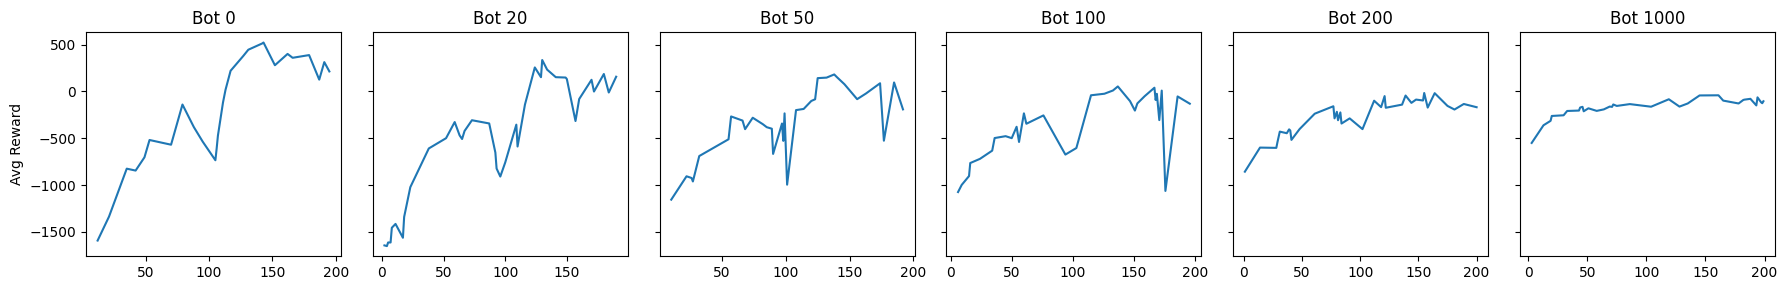

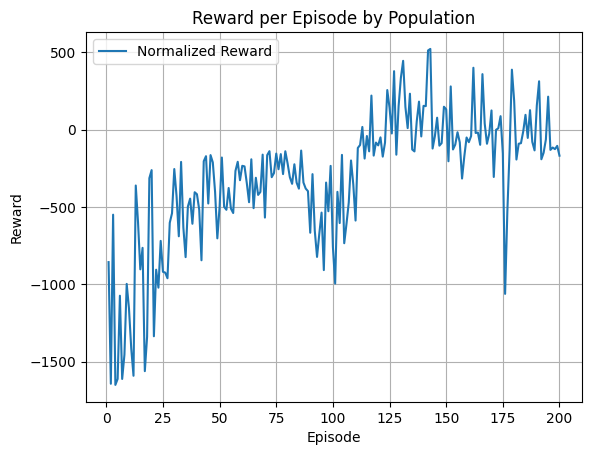

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

df = pd.read_json("5/metrics/metrics.jsonl", lines=True)
# df = pd.read_json("ablation/2/metrics.jsonl", lines=True)

df["avg_reward"] = df.reward / df.population

bot_types = df['bot_population'].unique()
bot_types.sort()

# plt.figure(figsize=(12, 3))
fig, axes = plt.subplots(1, 6, figsize=(18, 3), sharey=True)

for ax, bot_type in zip(axes, bot_types):
    filtered_df = df[df['bot_population'] == bot_type]
    episodes = filtered_df.index + 1
    ax.plot(episodes, filtered_df['avg_reward'], label=f'Bot {bot_type}')
    ax.set_title(f'Bot {bot_type}')
    
    # Episode number = index + 1
    episodes = filtered_df.index + 1
    
    # plt.plot(episodes, filtered_df['avg_reward'], label=f'Bot {bot_type}')

    # plt.xlabel('Episode')
    # plt.ylabel('Reward')
    # plt.title('Reward per Episode by Bot Population')
    # plt.legend(loc="upper left")
    # plt.grid(True)

# Only set ylabel once on the leftmost subplot
axes[0].set_ylabel('Avg Reward')

plt.tight_layout()
plt.show()

episodes = df.index + 1

plt.plot(episodes, df['avg_reward'], label=f'Normalized Reward')

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward per Episode by Population')
plt.legend()
plt.grid(True)
plt.show()

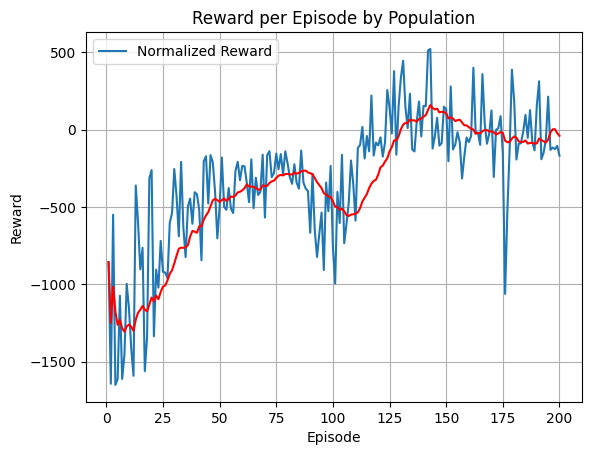

In [62]:
episodes = df.index + 1

WINDOW_SIZE = 20
ma = []

avg_reward = list(df.avg_reward)

for i, r in enumerate(avg_reward):
    num = i + 1
    if num < WINDOW_SIZE:
        ma.append(sum(avg_reward[:num]) / num)
    else:
        ma.append(sum(avg_reward[num-WINDOW_SIZE:num]) / WINDOW_SIZE)

plt.plot(episodes, df['avg_reward'], label=f'Normalized Reward')
plt.plot(episodes, ma, color="red")

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward per Episode by Population')
plt.legend()
plt.grid(True)
plt.show()
